In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from dataset import *
from itertools import product
from collections import Counter, OrderedDict
from rdkit import Chem
from rdkit.Chem import Draw
import os
from rmap import *

if not os.path.exists("../figures"):
    os.mkdir("../figures/")

## Preliminary data

In [2]:
data008b = pd.read_csv("../data/008b_final_report.csv")

raw_data_files = [
    pd.read_csv(
        f"../data/preliminary/{x:03}_final_report.csv",
        usecols=[
            "well", "reactant_1&smiles", "reactant_1&umol",
            "reactant_2&smiles", "reactant_2&umol",
            "catalyst_1&name", "catalyst_1&umol",
            "base_1&name", "base_1&umol",
            "solvent_1&name", "solvent_1&volume",
            "solvent_2&name", "solvent_2&volume",
            "suzuki_product_0__Estimated_%conversion"
        ]
    ) 
        for x in range(1, 7)
]
all_combined = pd.concat(raw_data_files).dropna()
print(all_combined.shape)

condition_columns = [
    "catalyst_1&name", "base_1&name", "solvent_1&name", 
    "reactant_1&umol", "reactant_2&umol", "catalyst_1&umol",
      "base_1&umol", "solvent_1&volume", "solvent_2&volume"
]

(2172, 14)


#### Plates 1 and 2

In [3]:
# Plates 1 and 2
plates1_2_df = pd.concat(raw_data_files[:2]).dropna()
unique_substrates_12 = plates1_2_df[["reactant_1&smiles", "reactant_2&smiles"]].drop_duplicates()
unique_substrate_pairs12 = [(x, y) for _, (x,y) in unique_substrates_12.iterrows()]

unique_reaction_conditions12 = plates1_2_df[condition_columns].drop_duplicates()
unique_reaction_conditions12 = [tuple(x) for _, x in unique_reaction_conditions12.iterrows()]

print(len(unique_substrate_pairs12), len(unique_reaction_conditions12))

16 4


In [4]:
count = np.zeros((16, 4))
yield_sum = np.zeros((16, 4))
for i, row in plates1_2_df.iterrows():
    row_ind = unique_substrate_pairs12.index(tuple(row[["reactant_1&smiles", "reactant_2&smiles"]]))
    col_ind = unique_reaction_conditions12.index(tuple(row[condition_columns]))
    count[row_ind, col_ind] += 1
    yield_sum[row_ind, col_ind] += row["suzuki_product_0__Estimated_%conversion"]

plates12_avg_yield = np.divide(yield_sum, count)

In [5]:
# The best reaction condition for each substrate pair.
# Reaction condition-0 is best for 12 substrates, out of 16.
np.argmax(plates12_avg_yield, axis=1)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3])

In [6]:
# List of reaction conditions.
unique_reaction_conditions12

[('XPhos Pd G4',
  'Na2CO3',
  'dioxane',
  '0.8 micromole',
  '0.9600000000000001 micromole',
  '0.16000000000000003 micromole',
  '6.0 micromole',
  '31.5 microliter',
  '3.5 microliter'),
 ('APhos Pd G3',
  'Na2CO3',
  'dioxane',
  '0.8 micromole',
  '0.9600000000000001 micromole',
  '0.16000000000000003 micromole',
  '6.0 micromole',
  '31.5 microliter',
  '3.5 microliter'),
 ('PCy Pd G4',
  'Na2CO3',
  'dioxane',
  '0.8 micromole',
  '0.9600000000000001 micromole',
  '0.16000000000000003 micromole',
  '6.0 micromole',
  '31.5 microliter',
  '3.5 microliter'),
 ('SPhos Pd G3',
  'Na2CO3',
  'dioxane',
  '0.8 micromole',
  '0.9600000000000001 micromole',
  '0.16000000000000003 micromole',
  '6.0 micromole',
  '31.5 microliter',
  '3.5 microliter')]

#### Plates 3 and 4

In [7]:
# Plates 3 and 4
plates34_df = pd.concat(raw_data_files[2:4]).dropna()
unique_substrates_34 = plates34_df[["reactant_1&smiles", "reactant_2&smiles"]].drop_duplicates()
unique_substrate_pairs34 = [(x, y) for _, (x,y) in unique_substrates_34.iterrows()]

unique_reaction_conditions34 = plates34_df[condition_columns].drop_duplicates()
unique_reaction_conditions34 = [tuple(x) for _, x in unique_reaction_conditions34.iterrows()]

print(len(unique_substrate_pairs34), len(unique_reaction_conditions34))

90 4


In [8]:
count = np.zeros((len(unique_substrate_pairs34), len(unique_reaction_conditions34)))
yield_sum = np.zeros((len(unique_substrate_pairs34), len(unique_reaction_conditions34)))
for i, row in plates34_df.iterrows():
    row_ind = unique_substrate_pairs34.index(tuple(row[["reactant_1&smiles", "reactant_2&smiles"]]))
    col_ind = unique_reaction_conditions34.index(tuple(row[condition_columns]))
    count[row_ind, col_ind] += 1
    yield_sum[row_ind, col_ind] += row["suzuki_product_0__Estimated_%conversion"]

plates34_avg_yield = np.divide(yield_sum, count)

In [9]:
# The number of substrates out of 90 evaluated where the 0-indexed condition performs the best
sum(np.argmax(plates34_avg_yield, axis=1) == 0)

73

In [10]:
# The best performing condition, same as previous two plates
unique_reaction_conditions34[0]

('XPhos Pd G4',
 'Na2CO3',
 'dioxane',
 '0.4 micromole',
 '0.48000000000000004 micromole',
 '0.08000000000000002 micromole',
 '3.0 micromole',
 '15.75 microliter',
 '1.75 microliter')

In [11]:
unique_reaction_conditions34[1:]

[('APhos Pd G3',
  'Na2CO3',
  'dioxane',
  '0.4 micromole',
  '0.48000000000000004 micromole',
  '0.08000000000000002 micromole',
  '3.0 micromole',
  '15.75 microliter',
  '1.75 microliter'),
 ('PdCl2(dcypf)',
  'Na2CO3',
  'dioxane',
  '0.4 micromole',
  '0.48000000000000004 micromole',
  '0.08000000000000002 micromole',
  '3.0 micromole',
  '15.75 microliter',
  '1.75 microliter'),
 ('tBuBrettPhos Pd G3',
  'Na2CO3',
  'dioxane',
  '0.4 micromole',
  '0.48000000000000004 micromole',
  '0.08000000000000002 micromole',
  '3.0 micromole',
  '15.75 microliter',
  '1.75 microliter')]

#### Plates 5 and 6

In [12]:
# Plates 5 and 6
plates56_df = pd.concat(raw_data_files[4:6]).dropna()
unique_substrates_56 = plates56_df[["reactant_1&smiles", "reactant_2&smiles"]].drop_duplicates()
unique_substrate_pairs56 = [(x, y) for _, (x,y) in unique_substrates_56.iterrows()]

unique_reaction_conditions56 = plates56_df[condition_columns].drop_duplicates()
unique_reaction_conditions56 = [tuple(x) for _, x in unique_reaction_conditions56.iterrows()]

print(len(unique_substrate_pairs56), len(unique_reaction_conditions56))

19 38


In [13]:
count = np.zeros((len(unique_substrate_pairs56), len(unique_reaction_conditions56)))
yield_sum = np.zeros((len(unique_substrate_pairs56), len(unique_reaction_conditions56)))
for i, row in plates56_df.iterrows():
    row_ind = unique_substrate_pairs56.index(tuple(row[["reactant_1&smiles", "reactant_2&smiles"]]))
    col_ind = unique_reaction_conditions56.index(tuple(row[condition_columns]))
    count[row_ind, col_ind] += 1
    yield_sum[row_ind, col_ind] += row["suzuki_product_0__Estimated_%conversion"]

plates56_avg_yield = np.divide(yield_sum, count)
plates56_avg_yield[np.where(count == 0)] = -1

/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_32145/2673591158.py:9: RuntimeWarning: invalid value encountered in divide
  plates56_avg_yield = np.divide(yield_sum, count)


<AxesSubplot: >

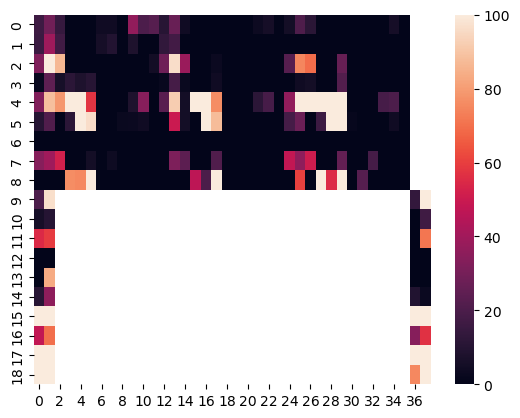

In [14]:
# Looking at the structure of the dataset.
sns.heatmap(plates56_avg_yield, vmax=100, mask=(plates56_avg_yield==-1))

In [15]:
# Looking at the average ranks of the 36 reaction conditions across the 9 substrates.
# Reaction condition at index 1 performs the best overall, coming in best place in 3 / 9 cases.
from scipy.stats import rankdata
average_ranks = np.mean(37 - rankdata(plates56_avg_yield[:9][:, :-2], axis=1), axis=0)
print(average_ranks)
print(np.argsort(average_ranks)[:3])

[12.16666667  7.94444444 11.61111111 16.27777778 15.05555556 14.38888889
 22.16666667 20.5        23.88888889 18.33333333 19.61111111 20.94444444
 16.5         8.5        15.88888889 20.5        17.5        13.66666667
 25.         25.         25.         22.94444444 22.27777778 25.
 15.66666667  9.22222222 14.         18.05555556 17.27777778 10.77777778
 24.         23.44444444 23.44444444 23.83333333 20.61111111 25.        ]
[ 1 13 25]


In [16]:
# Among the 36 reaction conditions, this condition at index-1 is the best performing overall.
unique_reaction_conditions56[1]

('XPhos Pd G4',
 'K3PO4',
 'dioxane',
 '0.266 micromole',
 '0.32000000000000006 micromole',
 '0.05325 micromole',
 '2.0 micromole',
 '10.8 microliter',
 '1.2000000000000002 microliter')

In [17]:
# In the remaining 10 substrates evaluated under 4 conditions, the same condition still performs best overall, 
# as seen by the rank value being closest to 1.
remaining_reactions = np.hstack((plates56_avg_yield[:9][:, :2], plates56_avg_yield[:9][:, -2:]))
print(remaining_reactions.shape)
average_ranks_remaining = np.mean(5 - rankdata(remaining_reactions, axis=1), axis=0)
print(average_ranks_remaining)

(9, 4)
[1.88888889 1.11111111 3.5        3.5       ]


### Looking at substrates evaluated in the first two pairs of plates

In [18]:
common_substrates = set(unique_substrate_pairs12) & set(unique_substrate_pairs34)  # 

In [19]:
dict_to_plot = {
    "Substrate pair index":[],
    "Plate 1&2 estimated conversion":[],
    "Plate 3&4 estimated conversion":[],
}

for i, (r1, r2) in enumerate(common_substrates):
    plates12_yields = plates1_2_df[
        (plates1_2_df["catalyst_1&name"] == "XPhos Pd G4") &\
        (plates1_2_df["base_1&name"] == "Na2CO3") &\
        (plates1_2_df["solvent_1&name"] == "dioxane") &\
        (plates1_2_df["reactant_1&smiles"] == r1) &\
        (plates1_2_df["reactant_2&smiles"] == r2) 
    ]["suzuki_product_0__Estimated_%conversion"].to_numpy()
    dict_to_plot["Substrate pair index"].append(i)
    dict_to_plot["Plate 1&2 estimated conversion"].append(float(np.mean(plates12_yields)))

    
    plates34_yields = plates34_df[
        (plates34_df["catalyst_1&name"] == "XPhos Pd G4") &\
        (plates34_df["base_1&name"] == "Na2CO3") &\
        (plates34_df["solvent_1&name"] == "dioxane") &\
        (plates34_df["reactant_1&smiles"] == r1) &\
        (plates34_df["reactant_2&smiles"] == r2) 
    ]["suzuki_product_0__Estimated_%conversion"].to_numpy()
    dict_to_plot["Plate 3&4 estimated conversion"].append(float(np.mean(plates34_yields)))

In [20]:
# Table S1
dict_to_plot

{'Substrate pair index': [0, 1, 2, 3, 4, 5, 6, 7],
 'Plate 1&2 estimated conversion': [8.323371304471078,
  123.12244404734179,
  132.98864215589978,
  29.700328718371058,
  13.775805899302945,
  147.13346729736938,
  25.754803057088864,
  45.244166434980954],
 'Plate 3&4 estimated conversion': [21.28036480783018,
  130.53874376316355,
  198.38936464507447,
  11.871294738137358,
  14.483010035969144,
  140.44792619163857,
  30.124499522671734,
  203.01214574687367]}

# Exploratory data analysis

In [2]:
# Saves a canonical processed table, where yields of reactions conducted multiple times are
# aggregated by taking the median of the non-zero values.
suzuki_data = SuzukiDataset(for_conventional_models=True, keepPhBr=True, from_notebook=True, save_excel=True)

raw_df = suzuki_data._raw_df
colors = sns.color_palette("colorblind", 8)

In [3]:
# Saves a canonical processed table, where yields of reactions conducted multiple times are
# aggregated by taking the median of ALL yield values.
all_median_suzuki_data = SuzukiDataset(
    for_conventional_models=True,
    keepPhBr=True,
    from_notebook=True,
    save_excel=True,
    exclude_zero_from_median=False
)
all_average_suzuki_data = SuzukiDataset(
    for_conventional_models=True,
    keepPhBr=True,
    from_notebook=True,
    save_excel=True,
    exclude_zero_from_median=False,
    aggregation="average"
)
maximum_suzuki_data = SuzukiDataset(
    for_conventional_models=True,
    keepPhBr=True,
    from_notebook=True,
    save_excel=True,
    exclude_zero_from_median=False,
    aggregation="maximum"
)

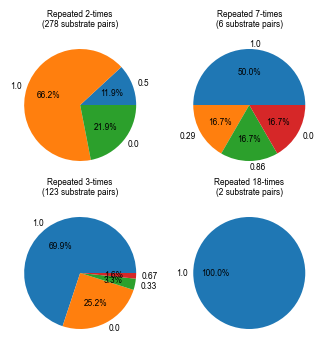

In [4]:
# Looking at all individual reactions' yields
# Figure S5A
all_halides = suzuki_data.core_smiles
all_boronics = suzuki_data.bb_smiles

nonzero_consistency_dict = {}

for halide_smiles, boronic_smiles in product(all_halides, all_boronics):
    sub_df = raw_df[(raw_df["reactant_1&smiles"]==halide_smiles) & (raw_df["reactant_2&smiles"]==boronic_smiles)]
    n_exp = sub_df.shape[0]
    if n_exp > 1 :
        if n_exp not in nonzero_consistency_dict.keys():
            nonzero_consistency_dict[n_exp] = [sum(sub_df["suzuki_product_CAD_yield"].values > 0) / sub_df.shape[0]]
        else : 
            nonzero_consistency_dict[n_exp].append(sum(sub_df["suzuki_product_CAD_yield"].values > 0) / sub_df.shape[0])

dict_for_pieplot = {}
for k, v in nonzero_consistency_dict.items():
    dict_for_pieplot.update({k:Counter(v)})
od = OrderedDict(sorted(dict_for_pieplot.items()))

fig, ax = plt.subplots(ncols=len(nonzero_consistency_dict.keys())//2, figsize=(4, 4), nrows=2)
for i, (k, v) in enumerate(od.items()):
    ax[i%2, i//2].pie(v.values(), labels=[round(x,2) for x in v.keys()], autopct='%1.1f%%', textprops={"family":"arial", "fontsize":6})
    ax[i%2, i//2].set_title(f"Repeated {k}-times\n({sum(v.values())} substrate pairs)", fontdict={"family":"arial", "fontsize":6})

if not os.path.exists("../figures"):
    os.mkdir("../figures")
if not os.path.exists("../figures/SI") :
    os.mkdir("../figures/SI")
# plt.savefig("../figures/SI/FigureS5A.svg", format="svg", dpi=300)

In [4]:
for halide_smiles, boronic_smiles in product(all_halides, all_boronics):
    sub_df = raw_df[(raw_df["reactant_1&smiles"]==halide_smiles) & (raw_df["reactant_2&smiles"]==boronic_smiles)]
    n_exp = sub_df.shape[0]
    if n_exp == 18 : 
        print(sub_df["suzuki_product_CAD_yield"].values)

[ 43.03952494 126.1655649  129.53971785 130.71009598  53.00877944
  59.91516079  84.82986644  62.80057071  61.53205476  86.68794991
  66.29125308  82.58480226  54.40921126 131.90892859  58.35724561
 130.87662053 151.8056653  149.8590876 ]
[  6.0738206   89.37842676  85.10553074  95.06130985  96.67000301
  94.27157757  87.33246591  90.02595293  92.9735292   88.97316805
  92.48250857  96.4468734   86.86687933  88.57845567  94.40101686
  91.69824725  96.63215132 112.9602933 ]


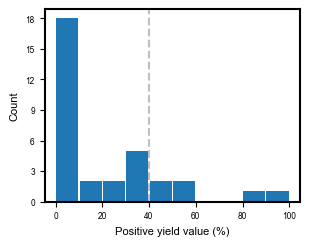

In [5]:
# Distribution of non zero yields when a reaction pair is repeated twice, and only one of the two reactions has a positive yield value.
# Figure S5B
duplicate_one_positive_yields = []
for halide_smiles, boronic_smiles in product(all_halides, all_boronics):
    sub_df = raw_df[(raw_df["reactant_1&smiles"]==halide_smiles) & (raw_df["reactant_2&smiles"]==boronic_smiles)]
    n_exp = sub_df.shape[0]
    if n_exp == 2 and sum(sub_df["suzuki_product_CAD_yield"].values > 0) == 1:
        duplicate_one_positive_yields.append(max(sub_df["suzuki_product_CAD_yield"].values))

fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.hist(duplicate_one_positive_yields, bins=np.arange(0,110,10), rwidth=0.95)
ax.set_yticks(np.arange(0, 19, 3))
ax.set_yticklabels(np.arange(0, 19, 3), fontdict={"family":"arial", "fontsize":6})
ax.set_xticks(np.arange(0, 110, 20))
ax.set_xticklabels(np.arange(0, 110, 20), fontdict={"family":"arial", "fontsize":6})
ax.set_xlabel("Positive yield value (%)", fontdict={"family":"arial", "fontsize":8})
ax.set_ylabel("Count", fontdict={"family":"arial", "fontsize":8})
ax.axvline(40, 0, 1, c="grey", ls="--", alpha=0.5)

for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(1.5)
# plt.savefig("../figures/SI/FigureS5B.svg", format="svg", dpi=300)

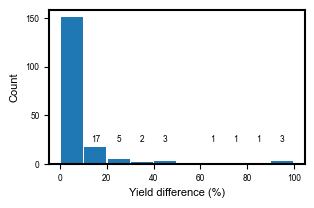

In [6]:
# Yield differences between reactions with the same substrate pair, when both reactions have positive yield values.
# Figure S5C
differences = []
stdevs = []
medians = []
for halide_smiles, boronic_smiles in product(all_halides, all_boronics):
    sub_df = raw_df[(raw_df["reactant_1&smiles"]==halide_smiles) & (raw_df["reactant_2&smiles"]==boronic_smiles)]
    n_exp = sub_df.shape[0]
    if n_exp == 2 and sum(sub_df["suzuki_product_CAD_yield"].values > 0) == 2:
        differences.append(max(sub_df["suzuki_product_CAD_yield"].values) - min(sub_df["suzuki_product_CAD_yield"].values))
    if n_exp >= 3 and sum(sub_df["suzuki_product_CAD_yield"].values > 0) == n_exp :
        stdevs.append(sub_df["suzuki_product_CAD_yield"].values.std())
        medians.append(np.median(sub_df["suzuki_product_CAD_yield"].values))

fig, ax = plt.subplots(figsize=(3.3, 2))
f = ax.hist(differences, bins=np.arange(0,110,10), rwidth=0.95)

ax.set_yticks(np.arange(0, 160, 50))
ax.set_yticklabels(np.arange(0, 160, 50), fontdict={"family":"arial", "fontsize":6})
ax.set_xticks(np.arange(0, 110, 20))
ax.set_xticklabels(np.arange(0, 110, 20), fontdict={"family":"arial", "fontsize":6})
ax.set_xlabel("Yield difference (%)", fontdict={"family":"arial", "fontsize":8})
ax.set_ylabel("Count", fontdict={"family":"arial", "fontsize":8})
for i, count in enumerate(f[0][1:]) :
    if count > 0 :
        ax.annotate(f"{int(count)}", xy=(10*(i+1)+5, 25), ha="center", va="center", fontsize=6, fontfamily="arial")
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(1.5)
# plt.savefig("../figures/SI/FigureS5C.svg", format="svg", dpi=300)

In [7]:
np.sum(raw_df['suzuki_product_CAD_yield'] > 100), len(raw_df['suzuki_product_CAD_yield'])

(49, 1604)

In [8]:
single_over100 = 0
all_singles = 0
for halide_smiles, boronic_smiles in product(all_halides, all_boronics):
    sub_df = raw_df[(raw_df["reactant_1&smiles"]==halide_smiles) & (raw_df["reactant_2&smiles"]==boronic_smiles)]
    n_exp = sub_df.shape[0]
    if n_exp == 1 :
        all_singles += 1
        if sub_df["suzuki_product_CAD_yield"].values[0] > 100:
            single_over100 += 1
    elif n_exp == 2 :
        # if sub_df["suzuki_product_CAD_yield"].values[0] > 100 :
        median = round(np.median(sub_df["suzuki_product_CAD_yield"].values))
        if median > 50:
            print("MEDIAN", median )
            print(sub_df["suzuki_product_CAD_yield"].values)
            print()
print(single_over100, all_singles)
    # if n_exp >= 3 and sum(sub_df["suzuki_product_CAD_yield"].values > 0) == n_exp :
    #     if round(sub_df["suzuki_product_CAD_yield"].values.std(), 1) > 10 :
    #         print("STD", round(sub_df["suzuki_product_CAD_yield"].values.std(), 1), "MEDIAN", round(np.median(sub_df["suzuki_product_CAD_yield"].values)))
    #         print(sub_df["suzuki_product_CAD_yield"].values)
    #         print()

MEDIAN 52
[40.99286616 62.05229354]

MEDIAN 74
[63.35790714 83.97829895]

MEDIAN 78
[85.91399726 70.44787356]

MEDIAN 52
[50.3054654  54.48313162]

MEDIAN 119
[121.36093034 116.57423138]

MEDIAN 67
[65.564906   68.49850601]

MEDIAN 62
[62.20957053 61.9903504 ]

MEDIAN 82
[77.06737293 85.95124645]

MEDIAN 51
[54.43247589 47.10682424]

MEDIAN 57
[52.98496854 61.76800521]

MEDIAN 60
[56.77417428 62.69408595]

MEDIAN 90
[93.74972963 85.58760381]

MEDIAN 58
[58.07704937 58.1518374 ]

MEDIAN 59
[69.3496955  48.53048428]

MEDIAN 71
[68.15265488 74.59346334]

MEDIAN 57
[63.0226825  50.59446138]

MEDIAN 70
[73.93687268 66.64593265]

MEDIAN 67
[70.57908184 64.32018668]

MEDIAN 54
[96.19793812 12.01049568]

MEDIAN 95
[108.8086372   80.55584649]

MEDIAN 61
[84.51844706 37.96470133]

MEDIAN 59
[54.16548488 63.93498822]

MEDIAN 74
[78.83495415 69.76919411]

MEDIAN 138
[130.9796629 144.0793641]

MEDIAN 74
[123.4516587   25.48514435]

MEDIAN 97
[ 88.39360978 106.1174594 ]

MEDIAN 84
[117.0975607   50.

In [9]:
# Portion of substrate pairs with standard deviation of yields above 10%
len(np.where(np.array(stdevs)>10)[0]) / len(stdevs)

0.08791208791208792

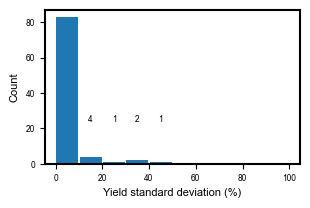

In [10]:
# Looking at the distribution of standard deviations of yields for substrate pairs with 3 or more positive yield values.
# Figure S5D
fig, ax = plt.subplots(figsize=(3.3, 2))
f = ax.hist(stdevs, bins=np.arange(0,110,10), rwidth=0.95)

ax.set_yticks(np.arange(0, 90, 20))
ax.set_yticklabels(np.arange(0, 90, 20), fontdict={"family":"arial", "fontsize":6})
ax.set_xticks(np.arange(0, 110, 20))
ax.set_xticklabels(np.arange(0, 110, 20), fontdict={"family":"arial", "fontsize":6})
ax.set_xlabel("Yield standard deviation (%)", fontdict={"family":"arial", "fontsize":8})
ax.set_ylabel("Count", fontdict={"family":"arial", "fontsize":8})
for i, count in enumerate(f[0][1:]) :
    if count > 0 :
        ax.annotate(f"{int(count)}", xy=(10*(i+1)+5, 25), ha="center", va="center", fontsize=6, fontfamily="arial")
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(1.5)
# plt.savefig("../figures/SI/FigureS5D.svg", format="svg", dpi=300)

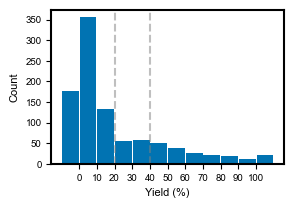

In [12]:
# Looking at distribution of yields after aggregating
# Figure S6A and Figure 2D
agg_df = suzuki_data.df

fig, ax = plt.subplots(figsize=(3, 2))
y = agg_df["suzuki_product_CAD_yield"].values.flatten()
y[y==0] = -1
y[y>100] = 100
plt.hist(y, bins=np.arange(-10,120, 10), rwidth=0.95, color=colors[0])
ax.set_yticks(np.arange(0,400,50))
ax.set_yticklabels(np.arange(0,400,50), fontdict={"family":"arial", "fontsize":7})
ax.set_xticks(np.arange(0,110,10))
ax.set_xticklabels(np.arange(0,110,10), fontdict={"family":"arial", "fontsize":7})
ax.set_xlabel("Yield (%)", fontdict={"family":"arial", "fontsize":8})
ax.set_ylabel("Count", fontdict={"family":"arial", "fontsize":8})
# ax.axvline(0, 0, 1, c="grey", ls="--", alpha=0.5)
ax.axvline(20, 0, 1, c="grey", ls="--", alpha=0.5)
ax.axvline(40, 0, 1, c="grey", ls="--", alpha=0.5)
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1.5)
plt.savefig("../figures/Figure2D.svg", format="svg", dpi=300)

In [ ]:
raw_df = suzuki_data._raw_df

tested_once = 0
large_diff_subs = []
for i, row in agg_df[agg_df["suzuki_product_CAD_yield"] > 100].iterrows():
    reactant1 = row["reactant_1&smiles"]
    reactant2 = row["reactant_2&smiles"]
    if raw_df.loc[(raw_df["reactant_1&smiles"]==reactant1) & (raw_df["reactant_2&smiles"]==reactant2)].shape[0] == 1:
        tested_once += 1
    else :
        if raw_df.loc[(raw_df["reactant_1&smiles"]==reactant1) &\
                      (raw_df["reactant_2&smiles"]==reactant2), 
                      "suzuki_product_CAD_yield"].values.min() <= 40 :
            large_diff_subs.append((reactant1, reactant2))
        print(raw_df.loc[(raw_df["reactant_1&smiles"]==reactant1) & (raw_df["reactant_2&smiles"]==reactant2), "suzuki_product_CAD_yield"])
        print()

print(agg_df[agg_df["suzuki_product_CAD_yield"] > 100].shape[0], "substrate pairs show >100% yield and", tested_once, "instances were reacted only once.")

69    126.892507
77    110.387802
85    105.722763
Name: suzuki_product_CAD_yield, dtype: float64

93     113.433825
101    105.443599
109    125.159153
Name: suzuki_product_CAD_yield, dtype: float64

669    121.360930
681    116.574231
Name: suzuki_product_CAD_yield, dtype: float64

1180    122.687290
1192    107.555272
1263     52.112134
Name: suzuki_product_CAD_yield, dtype: float64

1181    152.133610
1193    135.457318
1311     54.222121
Name: suzuki_product_CAD_yield, dtype: float64

1202    130.979663
1205    144.079364
Name: suzuki_product_CAD_yield, dtype: float64

1025    149.337940
1310     54.156732
Name: suzuki_product_CAD_yield, dtype: float64

1552    168.171377
1600    151.321790
Name: suzuki_product_CAD_yield, dtype: float64

21 substrate pairs show >100% yield and 13 instances were reacted only once.


In [15]:
tuple(raw_df[(raw_df["reactant_1&smiles"] == "CN1C=C(C)C=C(Br)C1=O") & (raw_df["reactant_2&smiles"] == "N#Cc1cc(F)cc(B(O)O)c1")].index)

(1203, 1206)

In [16]:
raw_df[(raw_df["reactant_1&smiles"] == "CN1C=C(C)C=C(Br)C1=O") & (raw_df["reactant_2&smiles"] == "N#Cc1cc(F)cc(B(O)O)c1")]

,reactant_1&smiles,reactant_1&name,reactant_2&smiles,reactant_2&name,suzuki_product_CAD_yield,plate
1203,CN1C=C(C)C=C(Br)C1=O,EN300-7046396,N#Cc1cc(F)cc(B(O)O)c1,417385123,123.451659,012
1206,CN1C=C(C)C=C(Br)C1=O,EN300-7046396,N#Cc1cc(F)cc(B(O)O)c1,417385123,25.485144,012


In [17]:
sdf = suzuki_data.df
sdf[(sdf["reactant_1&smiles"] == "CN1C=C(C)C=C(Br)C1=O") & (sdf["reactant_2&smiles"] == "N#Cc1cc(F)cc(B(O)O)c1")]

,reactant_1&smiles,reactant_1&name,reactant_2&smiles,reactant_2&name,suzuki_product_CAD_yield,plate
659,CN1C=C(C)C=C(Br)C1=O,EN300-7046396,N#Cc1cc(F)cc(B(O)O)c1,417385123,74.468402,"[012, 012]"


In [21]:
colorblind_palette = sns.color_palette("colorblind")

# Convert the palette to a list of hex codes
hex_codes = colorblind_palette.as_hex()

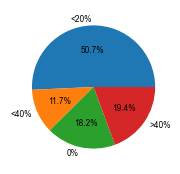

In [23]:
# Looking at the distribution of yields in 4 bins as divided by the yield thresholds: 0%, (0,20)%, [20,40)%, and >=40%
# Figure S6B
fig, ax = plt.subplots(figsize=(2, 2))

y_binned_counter = Counter(np.digitize(y, [0, 20, 40], right=False))
y_label_dict = {0:"0%", 1:"<20%", 2:"<40%", 3:">40%"}
ax.pie(
    y_binned_counter.values(), 
    labels=[y_label_dict[x] for x in y_binned_counter.keys()], 
    autopct='%1.1f%%', 
    textprops={"family":"arial", "fontsize":6}
)
plt.savefig("../figures/SI/FigureS6B.svg", format="svg", dpi=300)

CC1=C(N2CCCC2=O)C=CC(Br)=C1
CN1C=NC=C(C1=O)Br
CC1=C(C(=NN1C(C)C)N)Br
C1CON=C1C2=CC=C(C=C2)Br
C1=NC(=C(NC1=O)Cl)Br
Cc1c(Br)cnc2[nH]ccc12
COc1ccc(-c2nnc(Br)o2)cc1
BrC1=CC=CC=C1
CC(=O)N1CCCc2cc(Br)ccc12
CN1C=C(C)C=C(Br)C1=O
Brc1cccc2nccn12
C1C2C(=O)C=C(N3CCN(C(=O)C)CC3)OC=2C(Br)=CC=1C
CC(C)(C)OC(=O)N1CCN2C(=NC=C2Br)C1
C1C2N(C(C)C)C(SC)=NC=2C(F)=CC=1Br


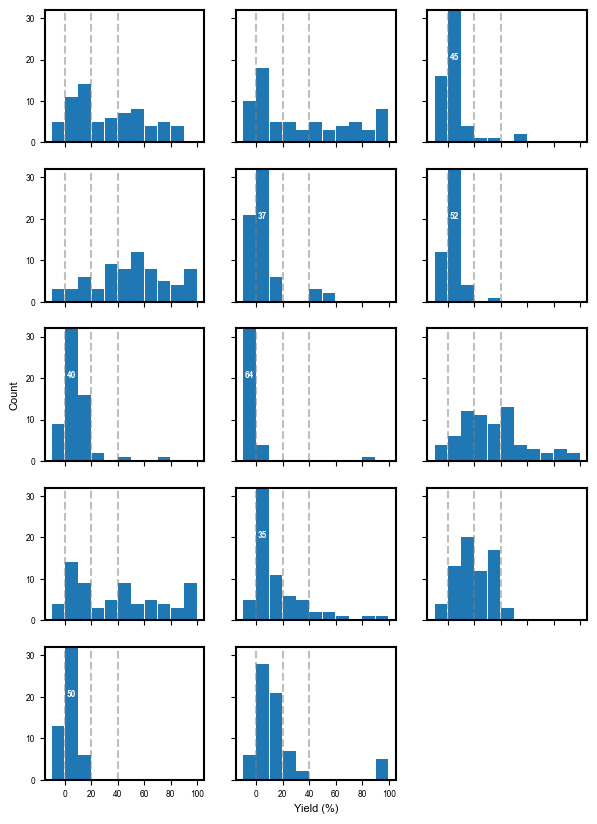

In [25]:
# Looking at yield distribution by halide
fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(7, 10), sharex=True, sharey=True)

for i, halide_smiles in enumerate(suzuki_data.core_smiles) :
    print(halide_smiles)
    y_one_halide = agg_df[agg_df["reactant_1&smiles"]==halide_smiles]["suzuki_product_CAD_yield"].values.flatten()
    y_one_halide[y_one_halide==0] = -1
    y_one_halide[y_one_halide>100] = 100

    count_vals, bins, _ = ax[i//3, i%3].hist(y_one_halide, bins=np.arange(-10,110, 10), rwidth=0.95)
    for c, (count, bin) in enumerate(zip(count_vals, bins)) :
        if count > 30 :
            ax[i//3, i%3].annotate(int(count), xy=(bin+5, 20), color="white", fontsize=6, fontfamily="arial", fontweight="bold", ha="center")

    ax[i//3, i%3].set_ylim((0,32))
    ax[i//3, i%3].set_yticks(np.arange(0,32,10))
    ax[i//3, i%3].set_xticks(np.arange(0,110,20))
    ax[i//3, i%3].axvline(0, 0, 1, c="grey", ls="--", alpha=0.5)
    ax[i//3, i%3].axvline(20, 0, 1, c="grey", ls="--", alpha=0.5)
    ax[i//3, i%3].axvline(40, 0, 1, c="grey", ls="--", alpha=0.5)
    if i%3 == 0 :
        ax[i//3, i%3].set_yticklabels(np.arange(0,32,10), fontdict={"family":"arial", "fontsize":6})
        if i//3 == 2:
            ax[i//3, i%3].set_ylabel("Count", fontdict={"family":"arial", "fontsize":8})
    if i//3 == 4:
        ax[i//3, i%3].set_xticklabels(np.arange(0,110,20), fontdict={"family":"arial", "fontsize":6})
        if i%3 == 1 :
            ax[i//3, i%3].set_xlabel("Yield (%)", fontdict={"family":"arial", "fontsize":8})
    for axis in ['top', 'bottom', 'left', 'right']:
        ax[i//3, i%3].spines[axis].set_linewidth(1.5)

ax[3, 2].set_xticklabels(np.arange(0,110,20), fontdict={"family":"arial", "fontsize":6})
ax[4, 2].axis("off")
plt.savefig("../figures/SI/FigureS7.svg", format="svg", dpi=300)

# Gephi analysis (Figure 3B and 5D)

In [ ]:
rmap4gephi = ReactivityMap(source_core_inds=None, target_core_ind=-1, test_bb_inds=[], dataset=suzuki_data)
rmap4gephi.get_similarity_matrix(gephi_filename="../data/gephi_files/full_suzuki_gephi_reactivity", tanimoto=False)
rmap4gephi.get_similarity_matrix(gephi_filename="../data/gephi_files/full_suzuki_gephi_tanimoto", tanimoto=True)

In [ ]:
suzuki_data = SuzukiDataset(for_conventional_models=False, keepPhBr=False, from_notebook=True, save_excel=False)
data_df = suzuki_data.df
source_cores = suzuki_data.core_smiles

### Larger differences

In [19]:
node03_smiles = "COc1ccc(B2OC(C)(C)C(C)(C)O2)cc1F"
node52_smiles = "CCOc1cc(B(O)O)ccc1F"

In [20]:
node03_info = data_df[(data_df["reactant_2&smiles"]==node03_smiles) & (data_df["reactant_1&smiles"].isin([source_cores[x] for x in [0, 1, 7]]))]
node03_info

,reactant_1&smiles,reactant_1&name,reactant_2&smiles,reactant_2&name,suzuki_product_CAD_yield,plate
2,CC1=C(N2CCCC2=O)C=CC(Br)=C1,1-(4-bromo-2-methylphenyl)pyrrolidin-2-one,COc1ccc(B2OC(C)(C)C(C)(C)O2)cc1F,417385164,9.820978,008b
71,CN1C=NC=C(C1=O)Br,"5-bromo-3-methyl-3,4-dihydropyrimidin-4-one",COc1ccc(B2OC(C)(C)C(C)(C)O2)cc1F,417385164,2.042746,008b
485,CC(=O)N1CCCc2cc(Br)ccc12,EN300-39492,COc1ccc(B2OC(C)(C)C(C)(C)O2)cc1F,417385164,25.154049,013


In [21]:
node52_info = data_df[(data_df["reactant_2&smiles"]==node52_smiles) & (data_df["reactant_1&smiles"].isin([source_cores[x] for x in [0, 1, 7]]))]
node52_info

,reactant_1&smiles,reactant_1&name,reactant_2&smiles,reactant_2&name,suzuki_product_CAD_yield,plate
51,CC1=C(N2CCCC2=O)C=CC(Br)=C1,1-(4-bromo-2-methylphenyl)pyrrolidin-2-one,CCOc1cc(B(O)O)ccc1F,417397463,81.749982,012
120,CN1C=NC=C(C1=O)Br,"5-bromo-3-methyl-3,4-dihydropyrimidin-4-one",CCOc1cc(B(O)O)ccc1F,417397463,76.840971,012
534,CC(=O)N1CCCc2cc(Br)ccc12,EN300-39492,CCOc1cc(B(O)O)ccc1F,417397463,87.274503,012


### Subtle differences

In [ ]:
node18_smiles = "Cc1ncccc1B(O)O"
node33_smiles = "COc1ccc(-c2ccc(B(O)O)cc2)cc1"


In [17]:
node33_info = data_df[(data_df["reactant_2&smiles"]==node33_smiles) & (data_df["reactant_1&smiles"].isin([source_cores[x] for x in [3, 8, 10]]))]
node33_info

,reactant_1&smiles,reactant_1&name,reactant_2&smiles,reactant_2&name,suzuki_product_CAD_yield,plate
239,C1CON=C1C2=CC=C(C=C2)Br,"3-(4-bromophenyl)-4,5-dihydro-1,2-oxazole",COc1ccc(-c2ccc(B(O)O)cc2)cc1,417714781,7.556155,"[010, 010, 010]"
584,CN1C=C(C)C=C(Br)C1=O,EN300-7046396,COc1ccc(-c2ccc(B(O)O)cc2)cc1,417714781,62.349423,013
722,C1C2C(=O)C=C(N3CCN(C(=O)C)CC3)OC=2C(Br)=CC=1C,WI00079341,COc1ccc(-c2ccc(B(O)O)cc2)cc1,417714781,32.042942,013


In [18]:
node18_info = data_df[(data_df["reactant_2&smiles"]==node18_smiles) & (data_df["reactant_1&smiles"].isin([source_cores[x] for x in [3, 8, 10]]))]
node18_info

,reactant_1&smiles,reactant_1&name,reactant_2&smiles,reactant_2&name,suzuki_product_CAD_yield,plate
224,C1CON=C1C2=CC=C(C=C2)Br,"3-(4-bromophenyl)-4,5-dihydro-1,2-oxazole",Cc1ncccc1B(O)O,417387330,44.503914,"[011, 011]"
569,CN1C=C(C)C=C(Br)C1=O,EN300-7046396,Cc1ncccc1B(O)O,417387330,0.312262,013
707,C1C2C(=O)C=C(N3CCN(C(=O)C)CC3)OC=2C(Br)=CC=1C,WI00079341,Cc1ncccc1B(O)O,417387330,3.795721,013


## Figure 5D

In [28]:
np.random.seed(42)
test_bb_inds = np.sort(
    np.random.choice(
        np.arange(suzuki_data.yield_array.shape[1]),
        14,  # Leaving 14 BBs out
        False,  # Not choosing the same building block multiple times
    )
)

fig5d_rmap = ReactivityMap(source_core_inds=None, target_core_ind=3, test_bb_inds=test_bb_inds, dataset=suzuki_data)

fig5d_rmap.get_similarity_matrix(gephi_filename="../data/gephi_files/core4_gephi_reactivity", tanimoto=False)
fig5d_selected_initial_BBs = fig5d_rmap.select_first_batch(n_select=6)
print([fig5d_rmap.train_bb_inds[x]+1  for x in fig5d_selected_initial_BBs])

[3, 68, 53, 63, 28, 50]


# Comparison of different yield aggregation schemes

In [ ]:
nonzero_median = SuzukiDataset(for_conventional_models=False, keepPhBr=True, from_notebook=True, save_excel=False)
all_median = SuzukiDataset(for_conventional_models=False, keepPhBr=True, from_notebook=True, save_excel=False, exclude_zero_from_median=False)
all_average = SuzukiDataset(for_conventional_models=False, keepPhBr=True, from_notebook=True, save_excel=False, aggregation="average", exclude_zero_from_median=False)
maximum = SuzukiDataset(for_conventional_models=False, keepPhBr=True, from_notebook=True, save_excel=False, aggregation="maximum", exclude_zero_from_median=False)

/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_62044/4149316860.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


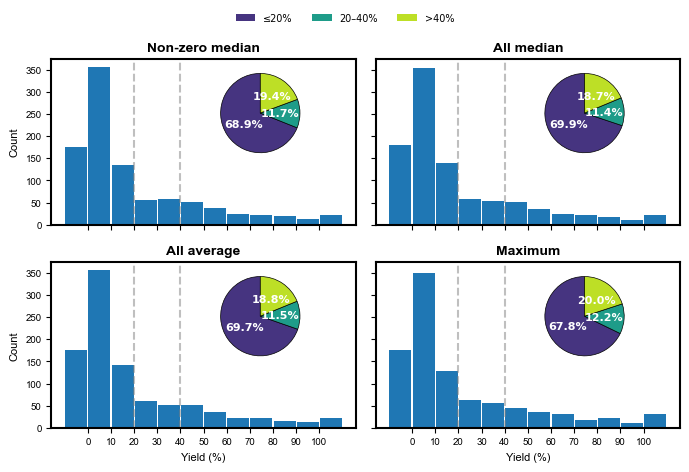

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cm

fig, ax = plt.subplots(figsize=(7, 4.5), ncols=2, nrows=2, sharex=True, sharey=True)
df_list = [nonzero_median.df, all_median.df, all_average.df, maximum.df]
title_list = ["Non-zero median", "All median", "All average", "Maximum"]
yield_values = []
for df in df_list:
    y = df["suzuki_product_CAD_yield"].values.flatten()
    y[y == 0] = -1
    y[y > 100] = 100
    yield_values.append(y)

# viridis-based colors for the three yield classes
pie_colors = [cm.viridis(0.15), cm.viridis(0.55), cm.viridis(0.9)]
pie_labels = ["≤20%", "20–40%", ">40%"]

for ind, y in enumerate(yield_values):
    row = ind // 2
    col = ind % 2

    ax[row, col].hist(y, bins=np.arange(-10, 120, 10), rwidth=0.95)

    if col == 0:
        ax[row, col].set_yticks(np.arange(0, 400, 50))
        ax[row, col].set_yticklabels(np.arange(0, 400, 50), fontdict={"family": "arial", "fontsize": 7})
        ax[row, col].set_ylabel("Count", fontdict={"family": "arial", "fontsize": 8})
    if row == 1:
        ax[row, col].set_xticks(np.arange(0, 110, 10))
        ax[row, col].set_xticklabels(np.arange(0, 110, 10), fontdict={"family": "arial", "fontsize": 7})
        ax[row, col].set_xlabel("Yield (%)", fontdict={"family": "arial", "fontsize": 8})

    ax[row, col].axvline(20, 0, 1, c="grey", ls="--", alpha=0.5)
    ax[row, col].axvline(40, 0, 1, c="grey", ls="--", alpha=0.5)

    ax[row, col].set_title(title_list[ind], fontdict={"family":"arial", "fontsize":10, "weight":"bold"})
    for axis in ['top', 'bottom', 'left', 'right']:
        ax[row, col].spines[axis].set_linewidth(1.5)

    # ---- Pie chart classification ----
    n_low = np.sum(y <= 20)
    n_mid = np.sum((y > 20) & (y <= 40))
    n_high = np.sum(y > 40)
    counts = [n_low, n_mid, n_high]

    # Create an inset axes in the top-right corner of the subplot
    axins = inset_axes(
        ax[row, col],
        width="60%", height="60%",
        loc="upper right",
        bbox_to_anchor=(0, 0, 1, 1),
        bbox_transform=ax[row, col].transAxes,
        borderpad=0.3
    )
    wedges, texts, autotexts = axins.pie(
        counts,
        colors=pie_colors,
        startangle=90,
        wedgeprops={"edgecolor": "black", "linewidth": 0.5},
        autopct="%.1f%%",
        pctdistance=0.5,
        textprops={"fontsize": 8}
    )

    # Optional: make percentage text more legible against viridis colors
    for autotext in autotexts:
        autotext.set_color("white")
        autotext.set_fontweight("bold")

    axins.set_aspect("equal")

# Single shared legend for all pie charts
fig.legend(
    [plt.Rectangle((0, 0), 1, 1, fc=c) for c in pie_colors],
    pie_labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=7,
    frameon=False
)

plt.tight_layout()
# plt.show()
# plt.savefig("../figures/SI/FigureS37.svg", format="svg", dpi=300)

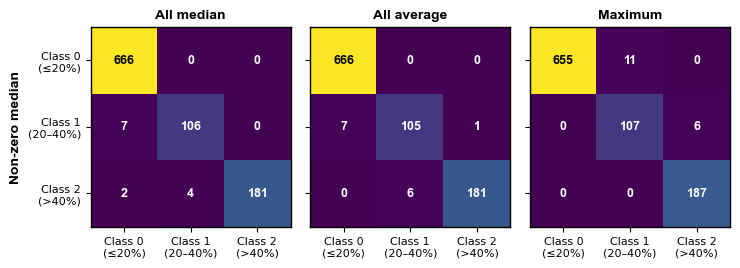

In [4]:
from sklearn.metrics import confusion_matrix

def classify_yield(y):
    """Classify yield values into 3 classes based on thresholds."""
    classes = np.zeros_like(y, dtype=int)
    classes[(y > 20) & (y <= 40)] = 1
    classes[y > 40] = 2
    return classes

# Reuse yield_values computed earlier (with -1/100 substitutions already applied)
class_labels = [classify_yield(y) for y in yield_values]

class_names = ["Class 0\n(≤20%)", "Class 1\n(20–40%)", "Class 2\n(>40%)"]
comparison_names = ["Non-zero median", "All median", "All average", "Maximum"]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 4), sharey=True)

for i in range(1, 4):
    cm = confusion_matrix(class_labels[0], class_labels[i], labels=[0, 1, 2])

    ax = axes[i - 1]
    im = ax.imshow(cm, cmap="viridis")

    # Annotate each cell with the count
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            val = cm[r, c]
            # choose text color for contrast against viridis background
            color = "white" if val < cm.max() * 0.6 else "black"
            ax.text(c, r, str(val), ha="center", va="center",
                     color=color, fontsize=9, fontweight="bold", fontfamily="arial")

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(class_names, fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    # ax.set_xlabel(comparison_names[i], fontsize=10)
    if i == 1:
        ax.set_ylabel(comparison_names[0], fontsize=10, fontweight="bold", fontfamily="arial")
    ax.set_title(f"{comparison_names[i]}", fontsize=10, fontweight="bold", fontfamily="arial")

    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1)


plt.tight_layout()
# plt.show()
# plt.savefig("../figures/SI/FigureS37.svg", format="svg", dpi=300)

In [21]:
# Now looking at which cores that the class changes occur -
core_smiles = np.unique(df_list[0]["reactant_1&smiles"])

# By taking All median and All average yields 6 reactions that is class-2 with non-zero median becomes class-0 or 1 
# and these cores are all different
for i in range(1, 3):
    diff_class_target_cores = []
    for diff_inds in np.where(class_labels[0] != class_labels[i])[0]:
        if class_labels[0][diff_inds] == 2 :
            diff_class_target_cores.append(core_smiles[diff_inds // 69])
    print(diff_class_target_cores)
    print()

# Where as three of the 6 reactions that become promoted from class-1 to 2 by taking the maximum value 
# come from the same core.
diff_class_target_cores = []
for diff_inds in np.where(class_labels[0] != class_labels[3])[0]:
    if class_labels[0][diff_inds] == 1 :
        diff_class_target_cores.append(core_smiles[diff_inds // 69])
print(diff_class_target_cores)

['Brc1cccc2nccn12', 'C1=NC(=C(NC1=O)Cl)Br', 'C1C2N(C(C)C)C(SC)=NC=2C(F)=CC=1Br', 'CC(C)(C)OC(=O)N1CCN2C(=NC=C2Br)C1', 'CC1=C(C(=NN1C(C)C)N)Br', 'CN1C=NC=C(C1=O)Br']

['Brc1cccc2nccn12', 'C1=NC(=C(NC1=O)Cl)Br', 'C1C2N(C(C)C)C(SC)=NC=2C(F)=CC=1Br', 'CC(C)(C)OC(=O)N1CCN2C(=NC=C2Br)C1', 'CC1=C(C(=NN1C(C)C)N)Br', 'CN1C=NC=C(C1=O)Br']

['Brc1cccc2nccn12', 'C1C2C(=O)C=C(N3CCN(C(=O)C)CC3)OC=2C(Br)=CC=1C', 'C1C2C(=O)C=C(N3CCN(C(=O)C)CC3)OC=2C(Br)=CC=1C', 'C1C2C(=O)C=C(N3CCN(C(=O)C)CC3)OC=2C(Br)=CC=1C', 'CN1C=C(C)C=C(Br)C1=O', 'CN1C=NC=C(C1=O)Br']


### Distribution of pairwise reactivity similarity

In [22]:
nonzero_rmap = ReactivityMap(
    source_core_inds=None, target_core_ind=-1, test_bb_inds=[], dataset=SuzukiDataset(from_notebook=True)
)
allmedian_rmap = ReactivityMap(
    source_core_inds=None, target_core_ind=-1, test_bb_inds=[], dataset=SuzukiDataset(from_notebook=True, exclude_zero_from_median=False)
)
allaverage_rmap = ReactivityMap(
    source_core_inds=None, target_core_ind=-1, test_bb_inds=[], dataset=SuzukiDataset(from_notebook=True, exclude_zero_from_median=False, aggregation="average")
)
maximum_rmap = ReactivityMap(
    source_core_inds=None, target_core_ind=-1, test_bb_inds=[], dataset=SuzukiDataset(from_notebook=True, exclude_zero_from_median=False, aggregation="maximum")
)

In [42]:
from itertools import product
rmaps = [nonzero_rmap, allmedian_rmap, allaverage_rmap, maximum_rmap]
portion_not_same_sims = np.zeros((4, 4))
for rmap1, rmap2 in product(rmaps, repeat=2):
    portion_not_same_sims[rmaps.index(rmap1), rmaps.index(rmap2)] = len(np.where(rmap1.get_similarity_matrix() != rmap2.get_similarity_matrix())[0])/ len(rmap2.get_similarity_matrix().flatten())

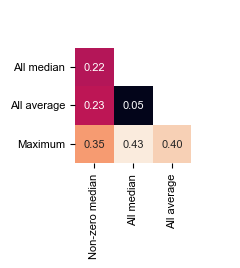

In [52]:
aggs = ["Non-zero median", "All median", "All average", "Maximum"]

mask = np.triu(np.ones_like(portion_not_same_sims, dtype=bool))

fig, ax = plt.subplots(figsize=(2, 2))
sns.heatmap(portion_not_same_sims, annot=True, fmt=".2f", annot_kws={"fontfamily":"arial", "fontsize":8}, cbar=False, mask=mask)
ax.set_yticks([1.5,2.5,3.5])
ax.set_yticklabels(aggs[1:], fontdict={"family":"arial","size":8}, rotation=0)
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(aggs[:-1], fontdict={"family":"arial","size":8}, rotation=90)
plt.savefig("../figures/SI/FigureS41B.svg", format="svg", dpi=300)

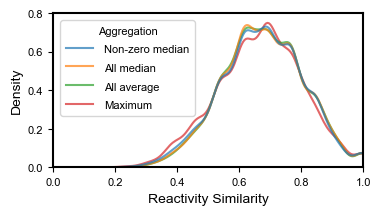

In [33]:
sim_mats = [x.get_similarity_matrix().flatten() for x in rmaps]
sim_dict = {
    "Aggregation":[],
    "Reactivity Similarity":[]
}
for agg, sim_mat in zip(aggs, sim_mats):
    sim_dict["Reactivity Similarity"].extend(list(sim_mat))
    sim_dict["Aggregation"].extend([agg]*len(sim_mat))
sim_df = pd.DataFrame(sim_dict)

fig, ax = plt.subplots(figsize=(4,2))
sns.kdeplot(sim_df, x="Reactivity Similarity", hue="Aggregation", ax=ax, alpha=0.7)
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1.5)
ax.set_ylabel("Density", fontdict={"family":"arial","size":10})
ax.set_xlabel("Reactivity Similarity", fontdict={"family":"arial","size":10})
ax.set_xlim(0, 1)
ax.set_xticks(np.arange(0, 1.1, 0.2))
ax.set_xticklabels([round(x, 1) for x in np.arange(0, 1.1, 0.2)], fontdict={"family":"arial","size":8})
ax.set_yticks(np.arange(0, 0.9, 0.2))
ax.set_yticklabels([round(x, 1) for x in np.arange(0, 0.9, 0.2)], fontdict={"family":"arial","size":8})

legend = ax.get_legend()
if legend is not None:
    # Legend title
    legend.get_title().set_fontfamily("Arial")
    legend.get_title().set_fontsize(8)
    legend.get_title().set_fontweight("normal")

    # Legend category labels
    for text in legend.get_texts():
        text.set_fontfamily("Arial")
        text.set_fontsize(8)

plt.savefig("../figures/SI/FigureS41A.svg", format="svg", dpi=300)

# Example use of dataset object

In [2]:
suzuki_data = SuzukiDataset(for_conventional_models=False, keepPhBr=False, from_notebook=True)
reactivity = suzuki_data.reactivity_array
print(reactivity.shape)
print(np.unique(reactivity))

(13, 69)
[0 1 2]


In [3]:
X_fp = suzuki_data.X_fp
print(X_fp.shape)

(13, 69, 2048)


In [ ]:
rmap = ReactivityMap(source_core_inds=None, target_core_ind=8, test_bb_inds=[], dataset=suzuki_data)

In [38]:
rmap.get_similarity_matrix()
sim_mat = rmap.similarity_matrix
print(sim_mat.shape)
print(np.mean(sim_mat), np.std(sim_mat))

(69, 69)
0.6887908702653504 0.1337334501804974


In [39]:
selected_initial_BBs = rmap.select_first_batch(n_select=6)
print(selected_initial_BBs)

[52, 11, 2, 62, 67, 58]


In [40]:
entire_rmap = ReactivityMap(source_core_inds=None, target_core_ind=-1, test_bb_inds=[], dataset=suzuki_data)
entire_rmap.get_similarity_matrix(gephi_filename="trial")

array([[1.        , 0.80769231, 0.69230769, ..., 0.53846154, 0.57692308,
        0.5       ],
       [0.80769231, 1.        , 0.69230769, ..., 0.65384615, 0.76923077,
        0.65384615],
       [0.69230769, 0.69230769, 1.        , ..., 0.84615385, 0.61538462,
        0.53846154],
       ...,
       [0.53846154, 0.65384615, 0.84615385, ..., 1.        , 0.69230769,
        0.65384615],
       [0.57692308, 0.76923077, 0.61538462, ..., 0.69230769, 1.        ,
        0.88461538],
       [0.5       , 0.65384615, 0.53846154, ..., 0.65384615, 0.88461538,
        1.        ]])

In [41]:
entire_rmap.get_similarity_matrix(gephi_filename="tanimoto", tanimoto=True)

array([[1.        , 0.265625  , 0.31481481, ..., 0.29824561, 0.21875   ,
        0.24615385],
       [0.265625  , 1.        , 0.2173913 , ..., 0.19178082, 0.16666667,
        0.44615385],
       [0.31481481, 0.2173913 , 1.        , ..., 0.28333333, 0.28571429,
        0.23529412],
       ...,
       [0.29824561, 0.19178082, 0.28333333, ..., 1.        , 0.37704918,
        0.22535211],
       [0.21875   , 0.16666667, 0.28571429, ..., 0.37704918, 1.        ,
        0.16666667],
       [0.24615385, 0.44615385, 0.23529412, ..., 0.22535211, 0.16666667,
        1.        ]])